# MelodyMatch-V2 — Deep Model Comparison

This notebook compares the main deep-learning architectures evaluated on Mel spectrogram inputs.

Models:

- CNN
- CNN + BiLSTM
- CNN + Transformer
- CNN + Transformer + Metadata
- CNN + BiLSTM + Attention
- CNN + Multi-Scale

Evaluation metrics:

- Accuracy
- Balanced Accuracy
- Macro-F1
- Weighted-F1

No training is performed in this notebook. Results are loaded from completed experiments.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

FIGURES_DIR = Path("../results/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "results").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

METRICS_DIR = PROJECT_ROOT / "results" / "metrics"

In [3]:
model_files = {
    "CNN": "cnn_baseline.csv",
    "CNN + BiLSTM": "cnn_bilstm.csv",
    "CNN + Transformer": "cnn_transformer.csv",
    "CNN + Transformer + Metadata": "cnn_transformer_metadata.csv",
    "CNN + BiLSTM + Attention": "cnn_bilstm_attention.csv",
    "CNN + Multi-Scale": "cnn_multiscale.csv",
}

In [4]:
deep_results = {}

for model_name, filename in model_files.items():
    path = METRICS_DIR / filename
    
    if not path.exists():
        print(f"Missing: {path}")
        continue
    
    deep_results[model_name] = pd.read_csv(path)

print("Loaded experiments:")
for model_name in deep_results:
    print("-", model_name)

Loaded experiments:
- CNN
- CNN + BiLSTM
- CNN + Transformer
- CNN + Transformer + Metadata
- CNN + BiLSTM + Attention
- CNN + Multi-Scale


In [5]:
for model_name, df in deep_results.items():
    print(f"\n{model_name}")
    print(df.columns.tolist())
    display(df)


CNN
['split', 'loss', 'accuracy', 'balanced_accuracy', 'macro_f1', 'weighted_f1']


,split,loss,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,train,0.927073,0.664439,0.737287,0.591847,0.682237
1,validation,1.390619,0.642971,0.504557,0.460108,0.661304
2,test,1.470634,0.606143,0.515804,0.452737,0.624294



CNN + BiLSTM
['split', 'loss', 'accuracy', 'balanced_accuracy', 'macro_f1', 'weighted_f1']


,split,loss,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,train,0.927863,0.644695,0.736181,0.597575,0.659846
1,validation,1.557028,0.613818,0.480921,0.439839,0.627512
2,test,1.619257,0.575039,0.456477,0.411615,0.591878



CNN + Transformer
['split', 'loss', 'accuracy', 'balanced_accuracy', 'macro_f1', 'weighted_f1']


...

,model,best_epoch,best_val_macro_f1,test_loss,test_accuracy,test_balanced_accuracy,test_macro_f1,test_weighted_f1,trainable_parameters,metadata_dimension
0,CNN + Transformer + Metadata,18,0.294763,2.195474,0.409798,0.322114,0.293845,0.449175,3173840,86



CNN + BiLSTM + Attention
['model', 'best_epoch', 'parameter_count', 'train_loss', 'train_accuracy', 'train_balanced_accuracy', 'train_macro_f1', 'train_weighted_f1', 'val_loss', 'val_accuracy', 'val_balanced_accuracy', 'val_macro_f1', 'val_weighted_f1', 'test_loss', 'test_accuracy', 'test_balanced_accuracy', 'test_macro_f1', 'test_weighted_f1']


,model,best_epoch,parameter_count,train_loss,train_accuracy,train_balanced_accuracy,train_macro_f1,train_weighted_f1,val_loss,val_accuracy,val_balanced_accuracy,val_macro_f1,val_weighted_f1,test_loss,test_accuracy,test_balanced_accuracy,test_macro_f1,test_weighted_f1
0,CNN + BiLSTM + Attention,26,3051473,0.805502,0.672176,0.769846,0.616528,0.682593,1.536903,0.638179,0.50199,0.457764,0.650355,1.734316,0.585537,0.443084,0.393241,0.597511



CNN + Multi-Scale
['model', 'split', 'loss', 'accuracy', 'balanced_accuracy', 'macro_f1', 'weighted_f1']


,model,split,loss,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,Multi-Scale CNN,train,1.181902,0.640324,0.635154,0.502137,0.655472
1,Multi-Scale CNN,validation,1.423725,0.644169,0.496245,0.445931,0.655485
2,Multi-Scale CNN,test,1.545702,0.598367,0.479862,0.416151,0.609797


In [6]:
def get_test_metrics(df):
    # Format 1: train / validation / test rows
    if "split" in df.columns:
        row = df[
            df["split"].astype(str).str.lower() == "test"
        ].iloc[0]

        return {
            "Accuracy": row["accuracy"],
            "Balanced Accuracy": row["balanced_accuracy"],
            "Macro-F1": row["macro_f1"],
            "Weighted-F1": row["weighted_f1"],
        }

    # Format 2: single-row experiment summary
    else:
        row = df.iloc[0]

        return {
            "Accuracy": row["test_accuracy"],
            "Balanced Accuracy": row["test_balanced_accuracy"],
            "Macro-F1": row["test_macro_f1"],
            "Weighted-F1": row["test_weighted_f1"],
        }


deep_comparison = pd.DataFrame(
    {
        model_name: get_test_metrics(df)
        for model_name, df in deep_results.items()
    }
).T

deep_comparison

,Accuracy,Balanced Accuracy,Macro-F1,Weighted-F1
CNN,0.606143,0.515804,0.452737,0.624294
CNN + BiLSTM,0.575039,0.456477,0.411615,0.591878
CNN + Transformer,0.486003,0.367951,0.276709,0.484489
CNN + Transformer + Metadata,0.409798,0.322114,0.293845,0.449175
CNN + BiLSTM + Attention,0.585537,0.443084,0.393241,0.597511
CNN + Multi-Scale,0.598367,0.479862,0.416151,0.609797


In [7]:
deep_comparison_percent = deep_comparison * 100
deep_comparison_percent.round(2)

,Accuracy,Balanced Accuracy,Macro-F1,Weighted-F1
CNN,60.61,51.58,45.27,62.43
CNN + BiLSTM,57.50,45.65,41.16,59.19
CNN + Transformer,48.60,36.80,27.67,48.45
CNN + Transformer + Metadata,40.98,32.21,29.38,44.92
CNN + BiLSTM + Attention,58.55,44.31,39.32,59.75
CNN + Multi-Scale,59.84,47.99,41.62,60.98


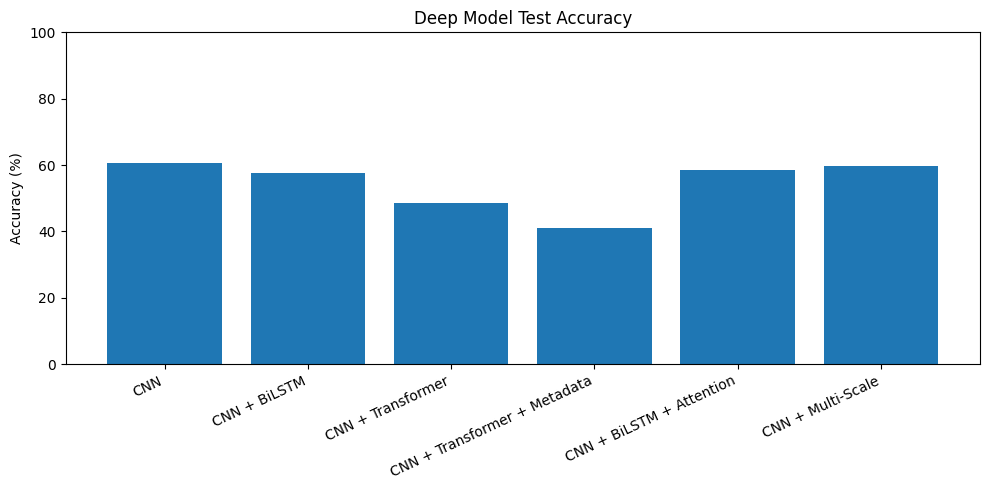

In [8]:
plt.figure(figsize=(10, 5))

plt.bar(
    deep_comparison_percent.index,
    deep_comparison_percent["Accuracy"],
)

plt.title("Deep Model Test Accuracy")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)

plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "deep_model_test_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

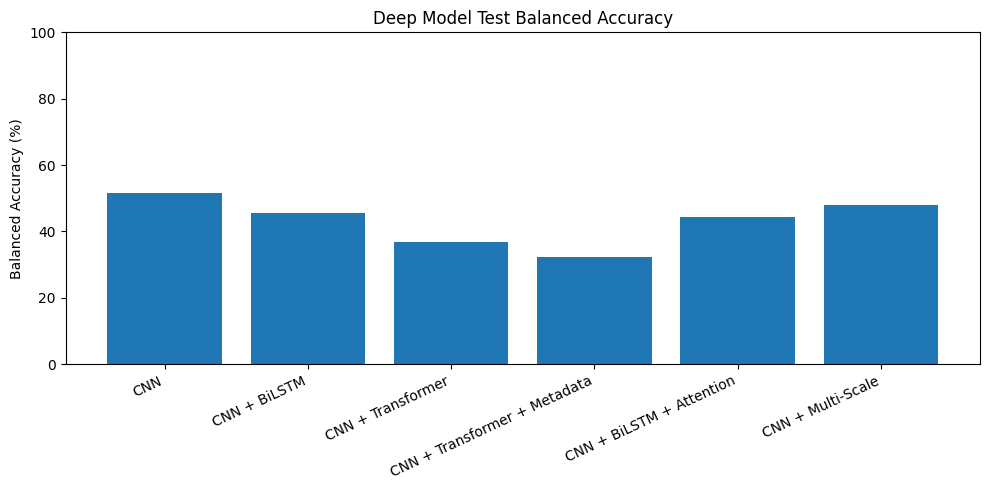

In [9]:
plt.figure(figsize=(10, 5))

plt.bar(
    deep_comparison_percent.index,
    deep_comparison_percent["Balanced Accuracy"],
)

plt.title("Deep Model Test Balanced Accuracy")
plt.ylabel("Balanced Accuracy (%)")
plt.ylim(0, 100)

plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "deep_model_test_balanced_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

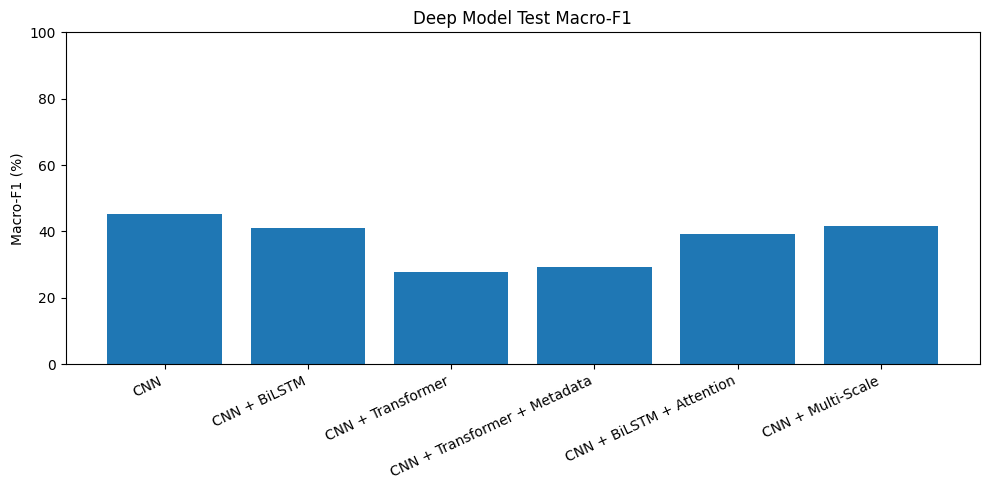

In [10]:
plt.figure(figsize=(10, 5))

plt.bar(
    deep_comparison_percent.index,
    deep_comparison_percent["Macro-F1"],
)

plt.title("Deep Model Test Macro-F1")
plt.ylabel("Macro-F1 (%)")
plt.ylim(0, 100)

plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "deep_model_test_macro_f1.png", dpi=300, bbox_inches="tight")
plt.show()

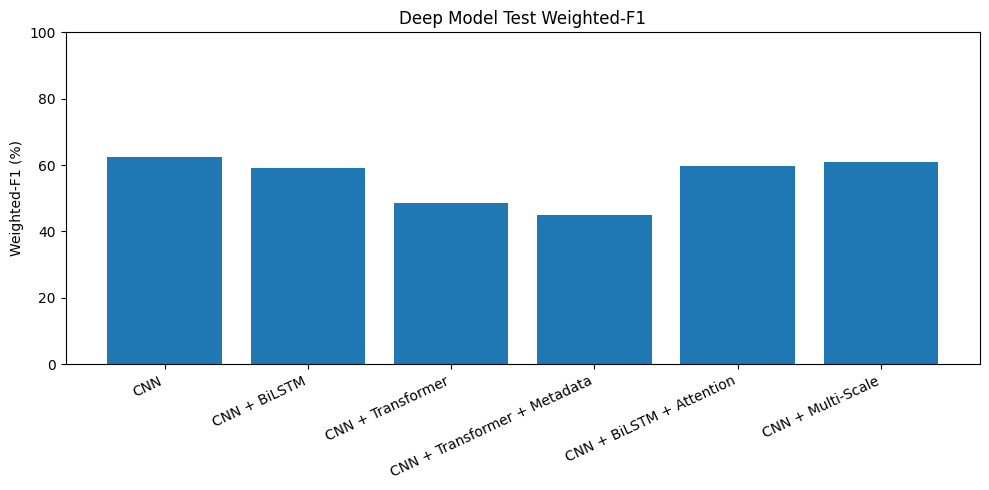

In [11]:
plt.figure(figsize=(10, 5))

plt.bar(
    deep_comparison_percent.index,
    deep_comparison_percent["Weighted-F1"],
)

plt.title("Deep Model Test Weighted-F1")
plt.ylabel("Weighted-F1 (%)")
plt.ylim(0, 100)

plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "deep_model_test_weighted_f1.png", dpi=300, bbox_inches="tight")
plt.show()

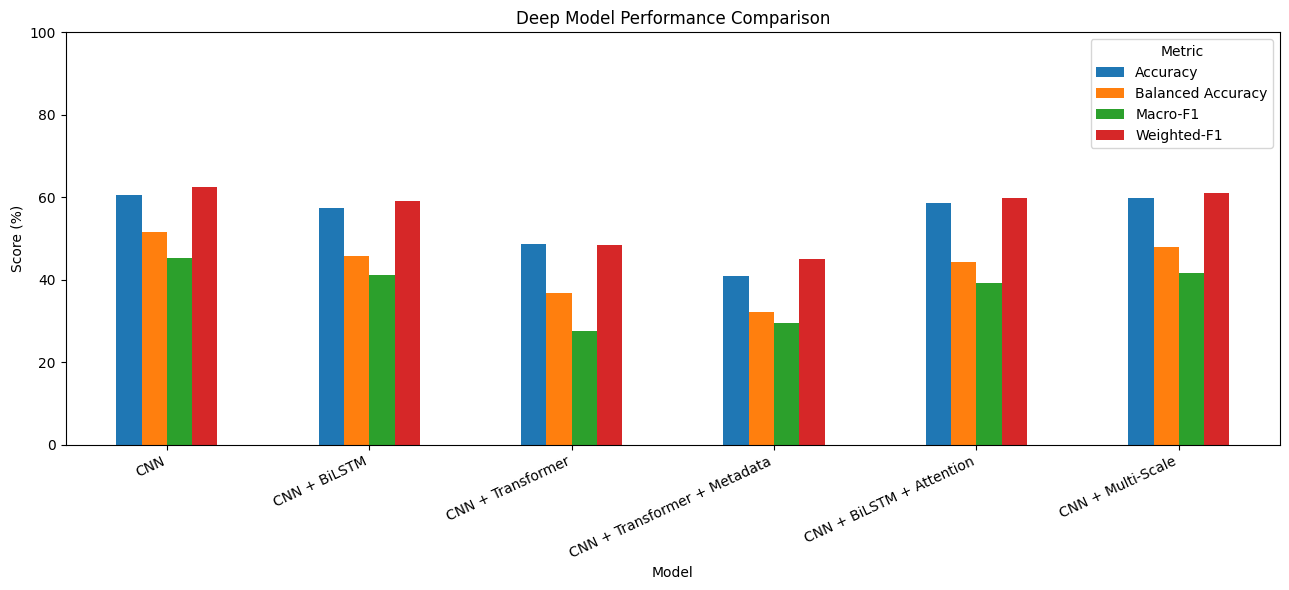

In [12]:
plot_df = deep_comparison_percent[
    [
        "Accuracy",
        "Balanced Accuracy",
        "Macro-F1",
        "Weighted-F1",
    ]
]

ax = plot_df.plot(
    kind="bar",
    figsize=(13, 6),
)

ax.set_title("Deep Model Performance Comparison")
ax.set_ylabel("Score (%)")
ax.set_xlabel("Model")
ax.set_ylim(0, 100)

plt.xticks(rotation=25, ha="right")
plt.legend(title="Metric")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "deep_model_performance_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
parameter_counts = pd.DataFrame({
    "Model": [
        "CNN",
        "CNN + BiLSTM",
        "CNN + Transformer",
        "CNN + Transformer + Metadata",
        "CNN + BiLSTM + Attention",
        "CNN + Multi-Scale",
    ],
    "Parameters": [
        392_912,
        3_018_448,
        3_047_376,
        3_173_840,
        3_051_473,
        403_216,
    ],
})

parameter_counts

,Model,Parameters
0,CNN,392912
1,CNN + BiLSTM,3018448
2,CNN + Transformer,3047376
3,CNN + Transformer + Metadata,3173840
4,CNN + BiLSTM + Attention,3051473
5,CNN + Multi-Scale,403216


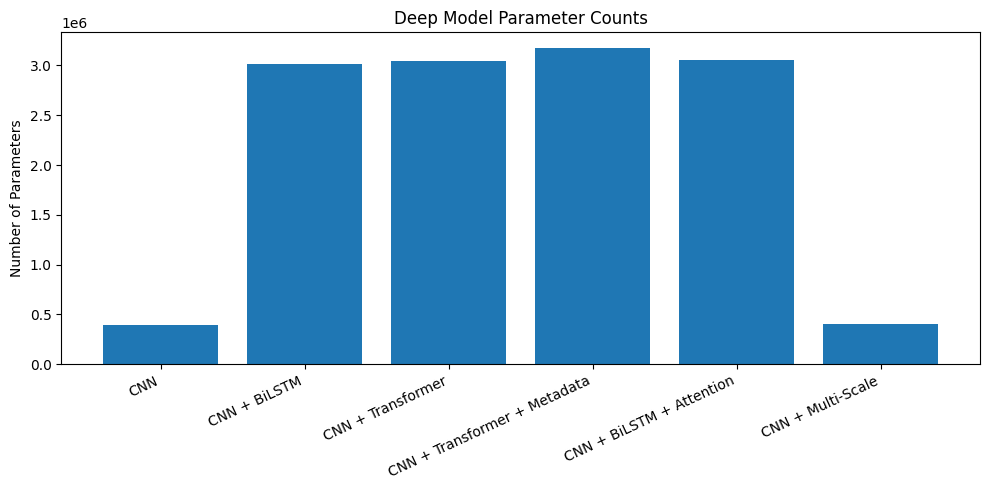

In [14]:
plt.figure(figsize=(10, 5))

plt.bar(
    parameter_counts["Model"],
    parameter_counts["Parameters"],
)

plt.title("Deep Model Parameter Counts")
plt.ylabel("Number of Parameters")

plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "deep_model_parameter_counts.png", dpi=300, bbox_inches="tight")
plt.show()

In [15]:
macro_f1_params = parameter_counts.merge(
    deep_comparison_percent[["Macro-F1"]],
    left_on="Model",
    right_index=True,
)

macro_f1_params

,Model,Parameters,Macro-F1
0,CNN,392912,45.273735
1,CNN + BiLSTM,3018448,41.161540
2,CNN + Transformer,3047376,27.670943
3,CNN + Transformer + Metadata,3173840,29.384487
4,CNN + BiLSTM + Attention,3051473,39.324065
5,CNN + Multi-Scale,403216,41.615101


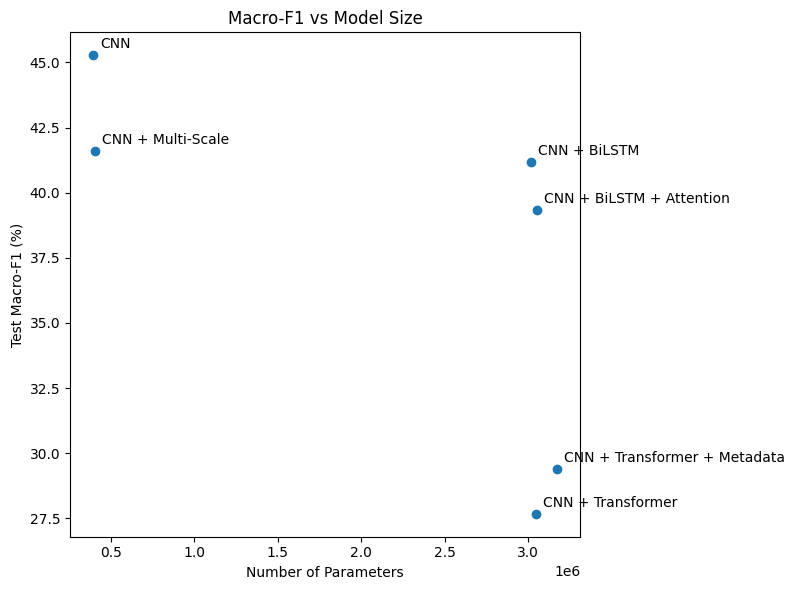

In [16]:
plt.figure(figsize=(8, 6))

plt.scatter(
    macro_f1_params["Parameters"],
    macro_f1_params["Macro-F1"],
)

for _, row in macro_f1_params.iterrows():
    plt.annotate(
        row["Model"],
        (row["Parameters"], row["Macro-F1"]),
        xytext=(5, 5),
        textcoords="offset points",
    )

plt.title("Macro-F1 vs Model Size")
plt.xlabel("Number of Parameters")
plt.ylabel("Test Macro-F1 (%)")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "deep_model_macro_f1_vs_model_size.png", dpi=300, bbox_inches="tight")
plt.show()

## Observations

- The CNN provides the strongest test Macro-F1 among the main deep-learning architectures evaluated.
- Adding a BiLSTM after the CNN feature extractor does not improve the test metrics relative to the CNN baseline.
- The CNN + Transformer model performs substantially below the CNN baseline under the evaluated configuration.
- Adding the selected metadata features to the Transformer model increases Macro-F1 relative to the CNN + Transformer model, but its overall test performance remains below the CNN baseline.
- The attention-based BiLSTM variant does not improve upon the simpler CNN or the original CNN + BiLSTM model.
- The multi-scale CNN does not improve over the standard CNN despite having a similar number of parameters.
- The results show that increasing architectural complexity does not automatically improve genre-classification performance on this dataset.
- Because FMA Medium is strongly imbalanced, Macro-F1 and Balanced Accuracy are important alongside raw accuracy.

In [17]:
deep_comparison_percent.round(4).to_csv(
    METRICS_DIR / "deep_model_comparison.csv"
)